<a href="https://colab.research.google.com/github/darreneasler/Assignment04/blob/main/Assignment04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
# Colab Setup and Data Download

import numpy as np
import matplotlib as plt
import pandas as pd
import gdown
print("pandas", pd.__version__)
print()
print("numpy", np.__version__)
print()
print("matplotlib", plt.__version__)
print()

csv_id = "1SUgKf0_fxFp28-0zJlh2hKCTbx_0Lx2m"
url = f"https://drive.google.com/uc?id={csv_id}"
gdown.download(url, "titanic.csv", quiet=False)

print()
dataset = pd.read_csv("titanic.csv")
print(dataset.shape)
print()
dataset.head()

pandas 2.2.2

numpy 2.0.2

matplotlib 3.10.0



Downloading...
From: https://drive.google.com/uc?id=1SUgKf0_fxFp28-0zJlh2hKCTbx_0Lx2m
To: /content/titanic.csv
100%|██████████| 60.3k/60.3k [00:00<00:00, 22.6MB/s]


(891, 12)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [95]:
# Data Checking
dataset.info()
print(dataset.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [96]:
# Setting the Target

target = dataset['Survived']
target.value_counts()

,count
Survived,
0,549
1,342


In [97]:
# Feature Definiton

remove_cols = ['PassengerId', 'Name', 'Cabin', 'Ticket']
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

dataset_cln = dataset.drop(columns=remove_cols)
print(dataset_cln.isnull().sum())
dataset_cln.head()



Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [98]:
# Fill Missing Values

dataset_cln['Age'] = dataset_cln['Age'].fillna(dataset_cln['Age'].median())
dataset_cln['Embarked'] = dataset_cln['Embarked'].fillna(dataset_cln['Embarked'].mode()[0])
print(dataset_cln.isnull().sum())

dataset_cln.head()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [99]:
# Categorical Feature Handling

dataset_cln = pd.get_dummies(dataset_cln, columns=['Sex', 'Embarked'], drop_first = True)
print(dataset_cln.info())
dataset_cln.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB
None


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [100]:
# Splitting Data

from sklearn.model_selection import train_test_split

X = dataset_cln.drop("Survived", axis = 1)
Y = dataset_cln['Survived']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


In [101]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)


In [102]:
# Decision Tree Evaluation

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

print("Confusion Matrix:")
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

print()

accuracy = accuracy_score(Y_test, Y_pred)
print(f"Accuracy: {accuracy:.3f}")

print()

precision = precision_score(Y_test, Y_pred)
print(f"Precision: {precision:.3f}")

print()

recall = recall_score(Y_test, Y_pred)
print(f"Recall: {recall:.3f}")

Confusion Matrix:
[[84 21]
 [18 56]]

Accuracy: 0.782

Precision: 0.727

Recall: 0.757


      Feature  Importance
5    Sex_male       0.310
4        Fare       0.256
1         Age       0.203
0      Pclass       0.115
2       SibSp       0.063
3       Parch       0.028
7  Embarked_S       0.020
6  Embarked_Q       0.005


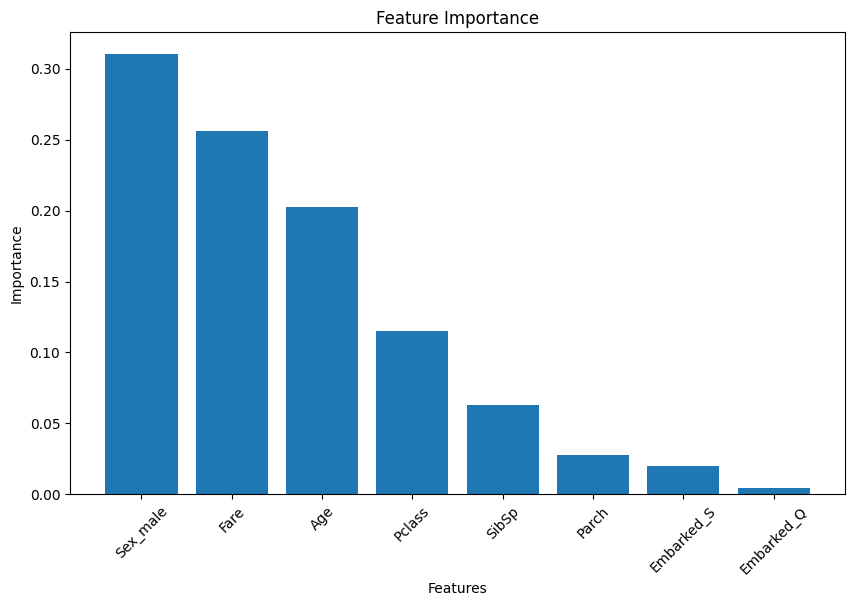

In [103]:
# Feature Importance and Visualization

import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance.round(3))

plt.figure(figsize=(10, 6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()